In [1]:
# =============================================================================
# ANALYSE EXPLORATOIRE DES DONNÉES DE SOL - SoilHive
# =============================================================================
# Objectifs:
#   1. Comprendre la distribution des propriétés du sol
#   2. Analyser la variabilité verticale (profondeur)
#   3. Examiner l'évolution temporelle
#   4. Explorer la variabilité spatiale
#   5. Identifier les opportunités pour la modélisation ML
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style scientifique sobre
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['figure.figsize'] = (10, 6)

# Palette de couleurs sobre (3 couleurs principales)
COLORS = ['#2c3e50', '#3498db', '#95a5a6']
COLORS_DEPTH = ['#1a5276', '#2980b9', '#5dade2', '#85c1e9']

# Chargement des données
df = pd.read_csv('../data/combined_output_data_points.csv')
print(f"Dataset chargé: {df.shape[0]:,} observations | {df.shape[1]} variables")
print(f"Période: {df['sampling_date'].min():.0f} - {df['sampling_date'].max():.0f}")

Dataset chargé: 1,278,483 observations | 14 variables
Période: 1918 - 2018


## 1. VUE D'ENSEMBLE DU DATASET

**Objectif:** Comprendre la structure, la qualité et la couverture des données.

In [2]:
# 1.1 Aperçu structurel
print("=" * 60)
print("STRUCTURE DU DATASET")
print("=" * 60)

# Types de données et valeurs manquantes
info_df = pd.DataFrame({
    'Type': df.dtypes,
    'Non-Null': df.count(),
    'Null (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique': df.nunique()
})
print(info_df)
print()

# Statistiques clés
print("=" * 60)
print("MÉTRIQUES CLÉS")
print("=" * 60)
print(f"• Propriétés du sol mesurées: {df['property'].nunique()}")
print(f"• Sources de données: {df['data_source'].nunique()}")
print(f"• Localisations uniques: {df[['lat', 'lon']].drop_duplicates().shape[0]:,}")
print(f"• Index H3 uniques (cellules spatiales): {df['h3_index'].nunique():,}")
print(f"• Plage de profondeur: {df['upper_depth_cm'].min():.0f} - {df['lower_depth_cm'].max():.0f} cm")

STRUCTURE DU DATASET
                     Type  Non-Null  Null (%)  Unique
id                  int64   1278483      0.00   18068
lat               float64   1278483      0.00   40516
lon               float64   1278483      0.00   40636
property           object   1278483      0.00      20
original_name      object   1278483      0.00      54
upper_depth_cm    float64   1254175      1.90     270
lower_depth_cm    float64   1254175      1.90     308
value             float64   1277382      0.09   14203
unit               object    971710     24.00      11
sampling_date     float64    687040     46.26      71
license            object   1278483      0.00       7
h3_index           object   1278483      0.00    1463
publication_date   object   1278483      0.00       3
data_source        object   1278483      0.00       3

MÉTRIQUES CLÉS
• Propriétés du sol mesurées: 20
• Sources de données: 3
• Localisations uniques: 41,651
• Index H3 uniques (cellules spatiales): 1,463
• Plage de profon

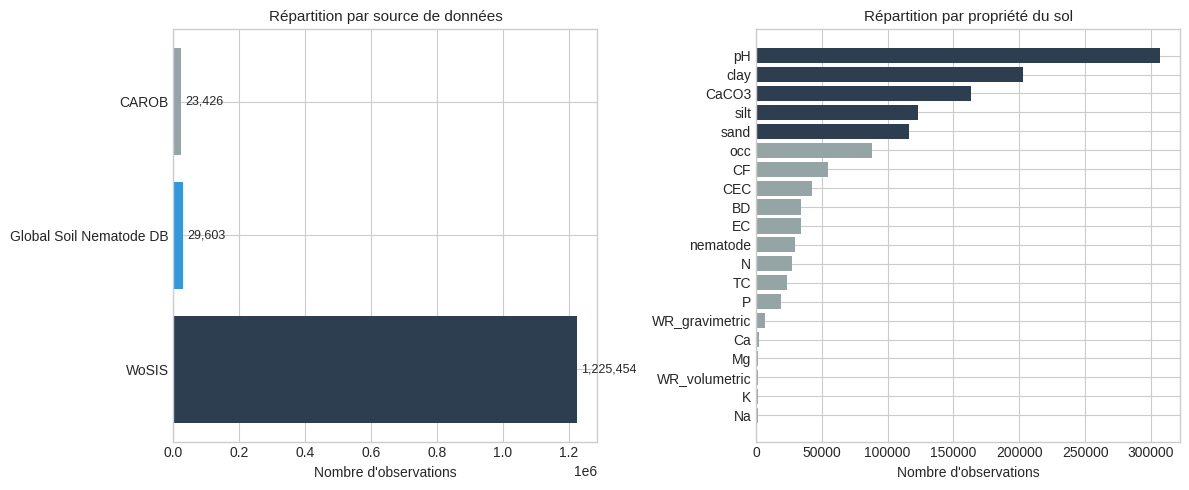


📌 INSIGHT: La source WoSIS domine largement. Les propriétés texturales
   (sand, clay, silt) et le pH sont les plus représentées.


In [3]:
# 1.2 Distribution par source de données et propriété
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribution par source
source_counts = df['data_source'].value_counts()
ax1 = axes[0]
bars = ax1.barh(source_counts.index, source_counts.values, color=COLORS[:len(source_counts)])
ax1.set_xlabel('Nombre d\'observations')
ax1.set_title('Répartition par source de données')
for bar, val in zip(bars, source_counts.values):
    ax1.text(val + max(source_counts)*0.01, bar.get_y() + bar.get_height()/2, 
             f'{val:,}', va='center', fontsize=9)

# Distribution par propriété
prop_counts = df['property'].value_counts()
ax2 = axes[1]
colors_prop = [COLORS[0] if i < 5 else COLORS[2] for i in range(len(prop_counts))]
bars = ax2.barh(prop_counts.index, prop_counts.values, color=colors_prop)
ax2.set_xlabel('Nombre d\'observations')
ax2.set_title('Répartition par propriété du sol')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# Insight
print("\n📌 INSIGHT: La source WoSIS domine largement. Les propriétés texturales")
print("   (sand, clay, silt) et le pH sont les plus représentées.")

## 2. DISTRIBUTION DES PROPRIÉTÉS DU SOL

**Objectif:** Caractériser la distribution statistique de chaque propriété, identifier les valeurs aberrantes et les asymétries.

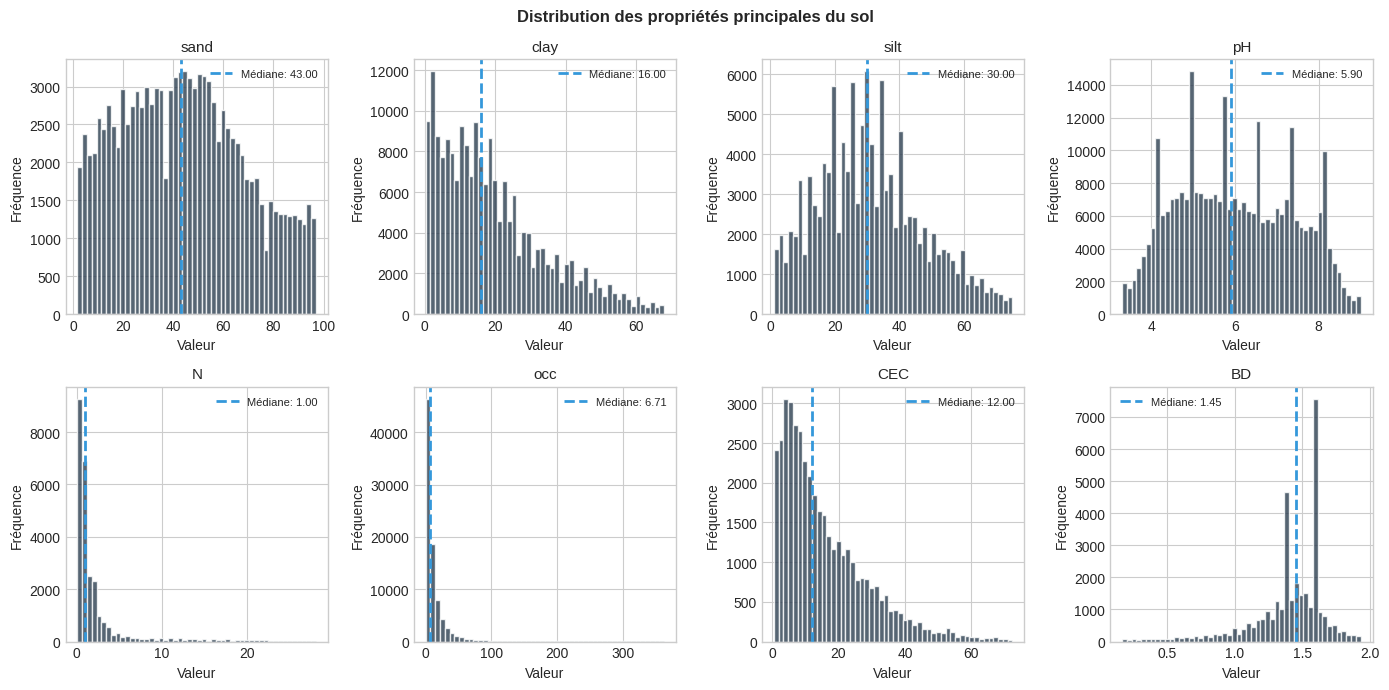


 INSIGHT: Le pH montre une distribution bimodale (sols acides vs alcalins).
   Les propriétés texturales (sand, clay, silt) sont fortement asymétriques.


In [4]:
# 2.2 Distribution des propriétés principales (histogrammes)
main_props = ['sand', 'clay', 'silt', 'pH', 'N', 'occ', 'CEC', 'BD']
available_props = [p for p in main_props if p in df['property'].unique()]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, prop in enumerate(available_props):
    ax = axes[i]
    data = df[df['property'] == prop]['value'].dropna()
    
    # Enlever les valeurs extrêmes pour la visualisation (percentile 1-99)
    q1, q99 = data.quantile([0.01, 0.99])
    data_clean = data[(data >= q1) & (data <= q99)]
    
    ax.hist(data_clean, bins=50, color=COLORS[0], edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color=COLORS[1], linestyle='--', linewidth=2, label=f'Médiane: {data.median():.2f}')
    ax.set_title(f'{prop}')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=8)

# Masquer les axes inutilisés
for j in range(len(available_props), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution des propriétés principales du sol', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n INSIGHT: Le pH montre une distribution bimodale (sols acides vs alcalins).")
print("   Les propriétés texturales (sand, clay, silt) sont fortement asymétriques.")

## 3. VARIABILITÉ VERTICALE (PROFONDEUR)

**Objectif:** Analyser comment les propriétés du sol varient avec la profondeur - essentiel pour la modélisation des profils de sol et les recommandations d'engrais.

In [5]:
df['depth_mid'] = (df['upper_depth_cm'] + df['lower_depth_cm']) / 2
df['depth_class'] = pd.cut(df['depth_mid'], 
                           bins=[0, 30, 60, 100, 200, np.inf],
                           labels=['0-30', '30-60', '60-100', '100-200', '>200'])

depth_dist = df['depth_class'].value_counts().sort_index()
print("Distribution des observations par classe de profondeur:")
print(depth_dist)
print(f"\nProfondeur médiane des échantillons: {df['depth_mid'].median():.0f} cm")

Distribution des observations par classe de profondeur:
depth_class
0-30       500255
30-60      306212
60-100     251910
100-200    192371
>200         3427
Name: count, dtype: int64

Profondeur médiane des échantillons: 40 cm


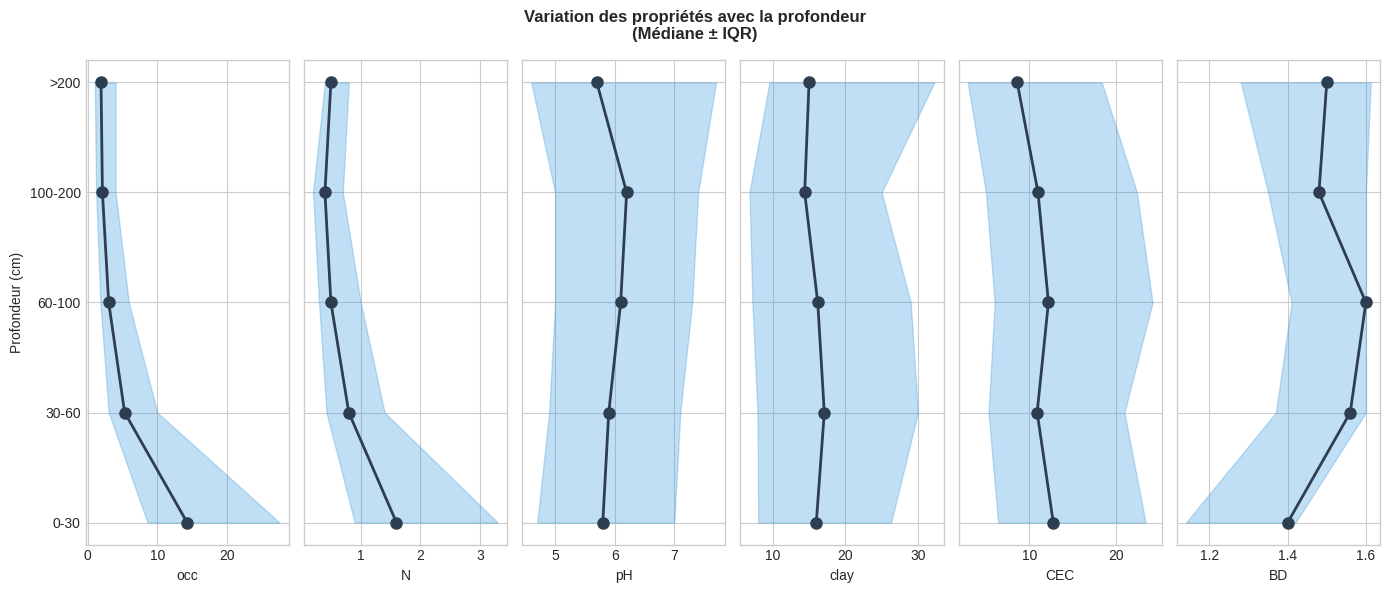


📌 INSIGHT AGRONOMIQUE:
   • Matière organique (occ) et azote (N): décroissance rapide avec la profondeur
   • pH: tendance à augmenter en profondeur (moins acide)
   • Argile (clay): accumulation possible dans les horizons intermédiaires (illuviation)
   ➜ Implication ML: la profondeur est une feature critique pour les modèles


In [6]:
key_props = ['occ', 'N', 'pH', 'clay', 'CEC', 'BD']
available_key = [p for p in key_props if p in df['property'].unique()]

fig, axes = plt.subplots(1, len(available_key), figsize=(14, 6), sharey=True)

for i, prop in enumerate(available_key):
    ax = axes[i]
    prop_data = df[df['property'] == prop].dropna(subset=['depth_class', 'value'])
    
    # Calculer médiane et IQR par classe de profondeur
    stats = prop_data.groupby('depth_class')['value'].agg(['median', 
        lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
    stats.columns = ['depth_class', 'median', 'q25', 'q75']
    
    # Convertir en positions numériques (inversées pour que surface soit en haut)
    positions = {'0-30': 0, '30-60': 1, '60-100': 2, '100-200': 3, '>200': 4}
    stats['y_pos'] = stats['depth_class'].map(positions)
    stats = stats.sort_values('y_pos')
    
    # Tracer le profil
    ax.plot(stats['median'], stats['y_pos'], 'o-', color=COLORS[0], linewidth=2, markersize=8)
    ax.fill_betweenx(stats['y_pos'], stats['q25'], stats['q75'], alpha=0.3, color=COLORS[1])
    
    ax.set_xlabel(prop)
    ax.set_yticks(range(5))
    ax.set_yticklabels(['0-30', '30-60', '60-100', '100-200', '>200'])
    ax.invert_yaxis()
    
    if i == 0:
        ax.set_ylabel('Profondeur (cm)')

plt.suptitle('Variation des propriétés avec la profondeur\n(Médiane ± IQR)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 INSIGHT AGRONOMIQUE:")
print("   • Matière organique (occ) et azote (N): décroissance rapide avec la profondeur")
print("   • pH: tendance à augmenter en profondeur (moins acide)")
print("   • Argile (clay): accumulation possible dans les horizons intermédiaires (illuviation)")
print("   ➜ Implication ML: la profondeur est une feature critique pour les modèles")

In [7]:
df['property'].value_counts().index

Index(['pH', 'clay', 'CaCO3', 'silt', 'sand', 'occ', 'CF', 'CEC', 'BD', 'EC',
       'nematode', 'N', 'TC', 'P', 'WR_gravimetric', 'Ca', 'Mg',
       'WR_volumetric', 'K', 'Na'],
      dtype='object', name='property')

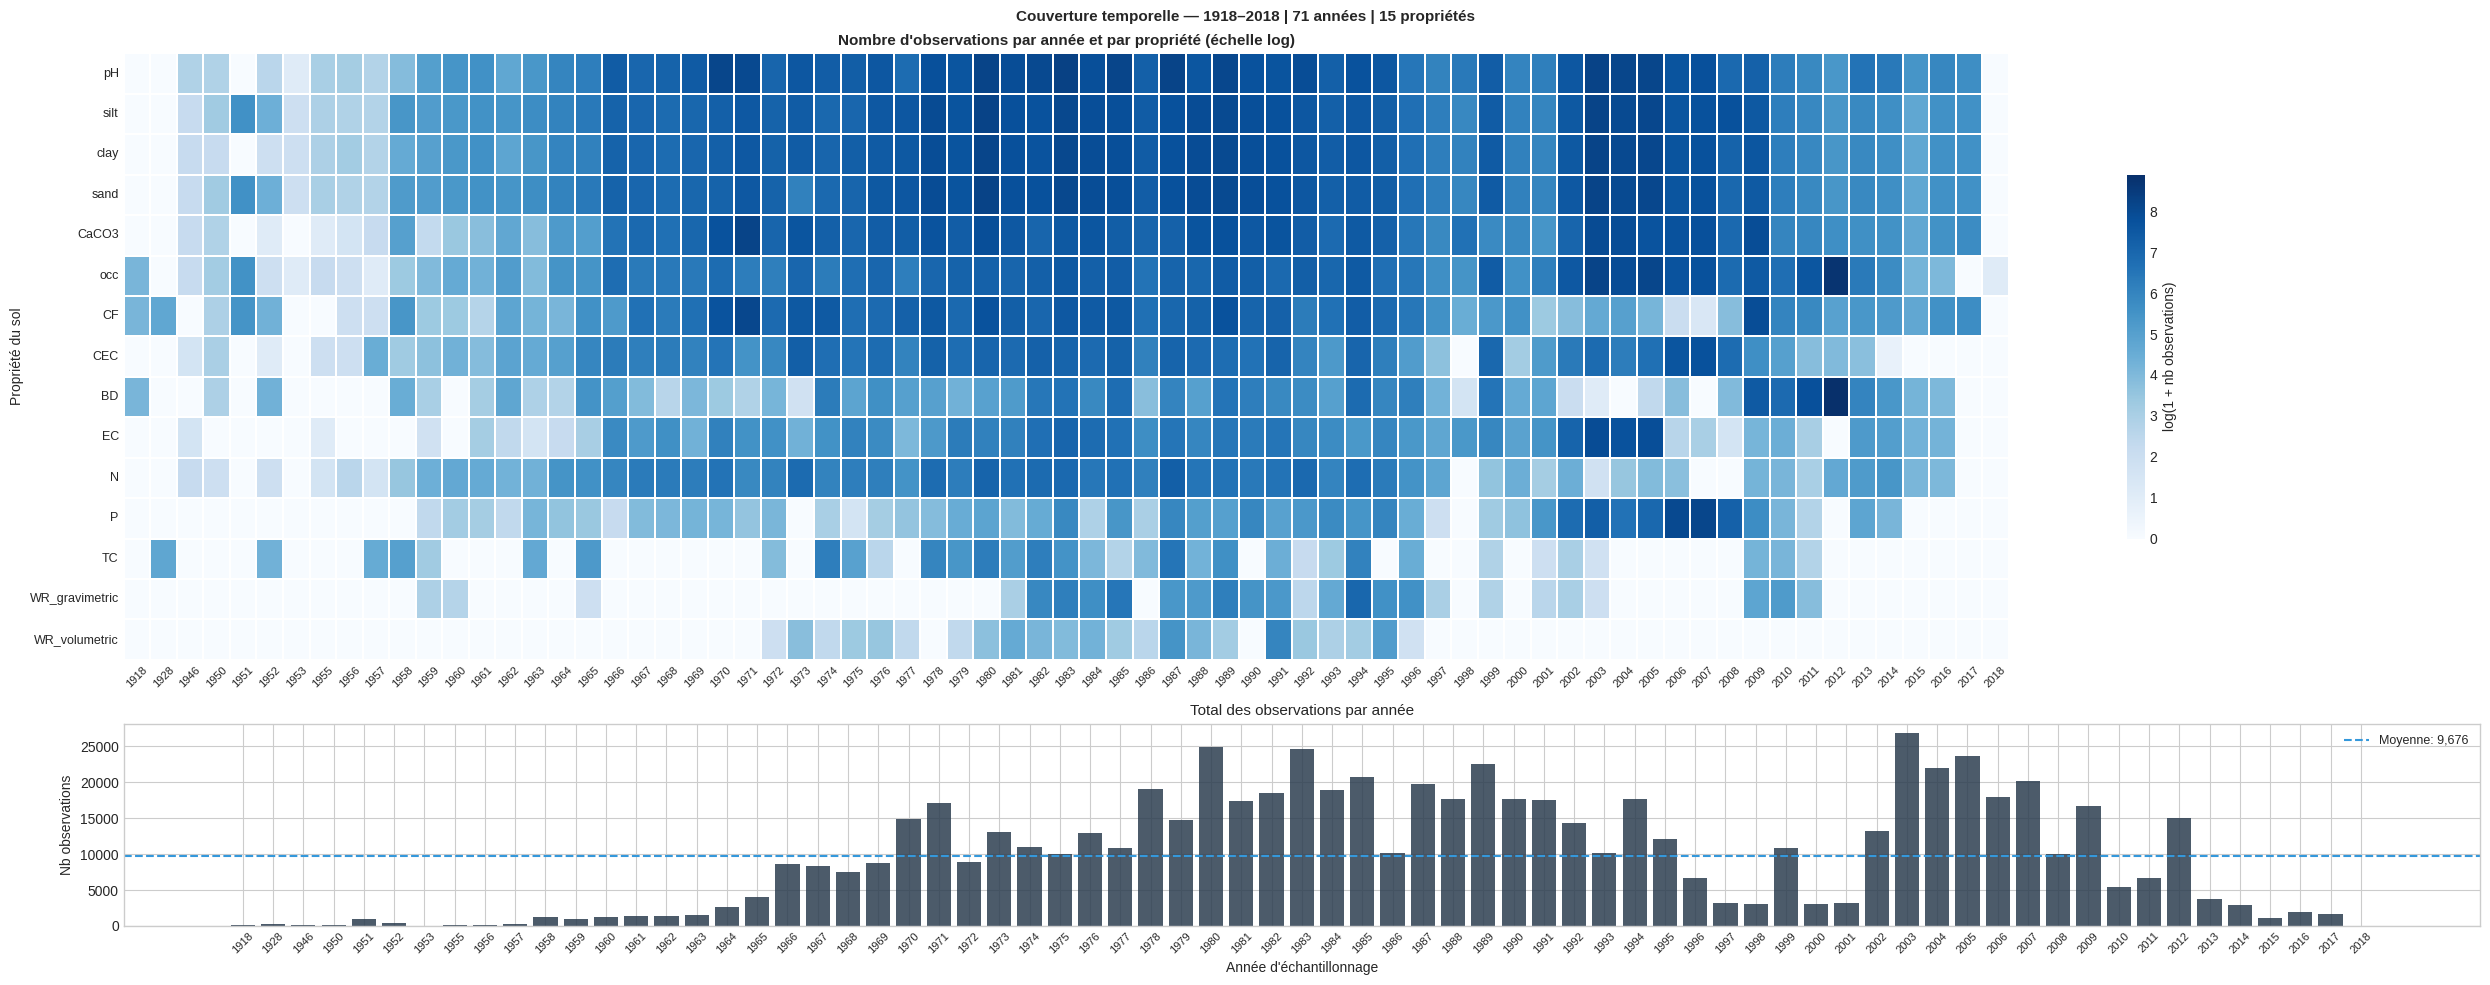


📊 STATISTIQUES TEMPORELLES:
   • Période couverte  : 1918 – 2018
   • Données avec date : 687,040 / 1,278,483 (53.7%)
   • Année la plus active : 2003 (26,820 observations)


In [8]:
df_temporal = df.dropna(subset=['sampling_date']).copy()
df_temporal['year'] = df_temporal['sampling_date'].astype(int)

# Matrice propriété × année (counts)
obs_matrix = (
    df_temporal.groupby(['property', 'year'])
    .size()
    .unstack(fill_value=0)
)

# Trier les propriétés par nombre total d'observations (décroissant)
obs_matrix = obs_matrix.loc[obs_matrix.sum(axis=1).sort_values(ascending=False).index]

fig, axes = plt.subplots(2, 1, figsize=(25, 10),
                         gridspec_kw={'height_ratios': [3, 1]})

# ── Heatmap : propriété × année ──────────────────────────────────────────────
ax1 = axes[0]
# Log1p pour atténuer l'effet des propriétés très dominantes (pH, clay…)
obs_log = np.log1p(obs_matrix)
sns.heatmap(
    obs_log, ax=ax1,
    cmap='Blues',
    linewidths=0.2,
    cbar_kws={'label': 'log(1 + nb observations)', 'shrink': 0.6}
)
ax1.set_xlabel('')
ax1.set_ylabel('Propriété du sol')
ax1.set_title('Nombre d\'observations par année et par propriété (échelle log)',
              fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', labelsize=9)

# ── Bar chart : total par année (toutes propriétés) ──────────────────────────
ax2 = axes[1]
total_per_year = df_temporal.groupby('year').size().sort_index()
years = total_per_year.index.astype(str)
x = range(len(years))

ax2.bar(x, total_per_year.values, color=COLORS[0], alpha=0.85, width=0.8)
ax2.axhline(total_per_year.mean(), color=COLORS[1], linestyle='--', linewidth=1.5,
            label=f'Moyenne: {int(total_per_year.mean()):,}')
ax2.set_xticks(x)
ax2.set_xticklabels(years, rotation=45, fontsize=8)
ax2.set_xlabel('Année d\'échantillonnage')
ax2.set_ylabel('Nb observations')
ax2.set_title('Total des observations par année')
ax2.legend(fontsize=9)

plt.suptitle(
    f'Couverture temporelle — {int(df_temporal["year"].min())}–{int(df_temporal["year"].max())} '
    f'| {df_temporal["year"].nunique()} années | {df_temporal["property"].nunique()} propriétés',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f"\n📊 STATISTIQUES TEMPORELLES:")
print(f"   • Période couverte  : {int(df_temporal['year'].min())} – {int(df_temporal['year'].max())}")
print(f"   • Données avec date : {len(df_temporal):,} / {len(df):,} ({len(df_temporal)/len(df)*100:.1f}%)")
peak_year = total_per_year.idxmax()
print(f"   • Année la plus active : {peak_year} ({total_per_year[peak_year]:,} observations)")

### 4.2 Évolution temporelle des valeurs

**Objectif :** Déterminer si les valeurs médianes des propriétés du sol ont changé au fil du temps.  
Pour chaque propriété, on calcule la **médiane annuelle** (sur les années avec ≥ 10 observations), on trace la série temporelle avec sa bande d'incertitude (IQR 25–75), puis on ajuste une **régression linéaire** pour quantifier la tendance et tester sa significativité (test t de Student).

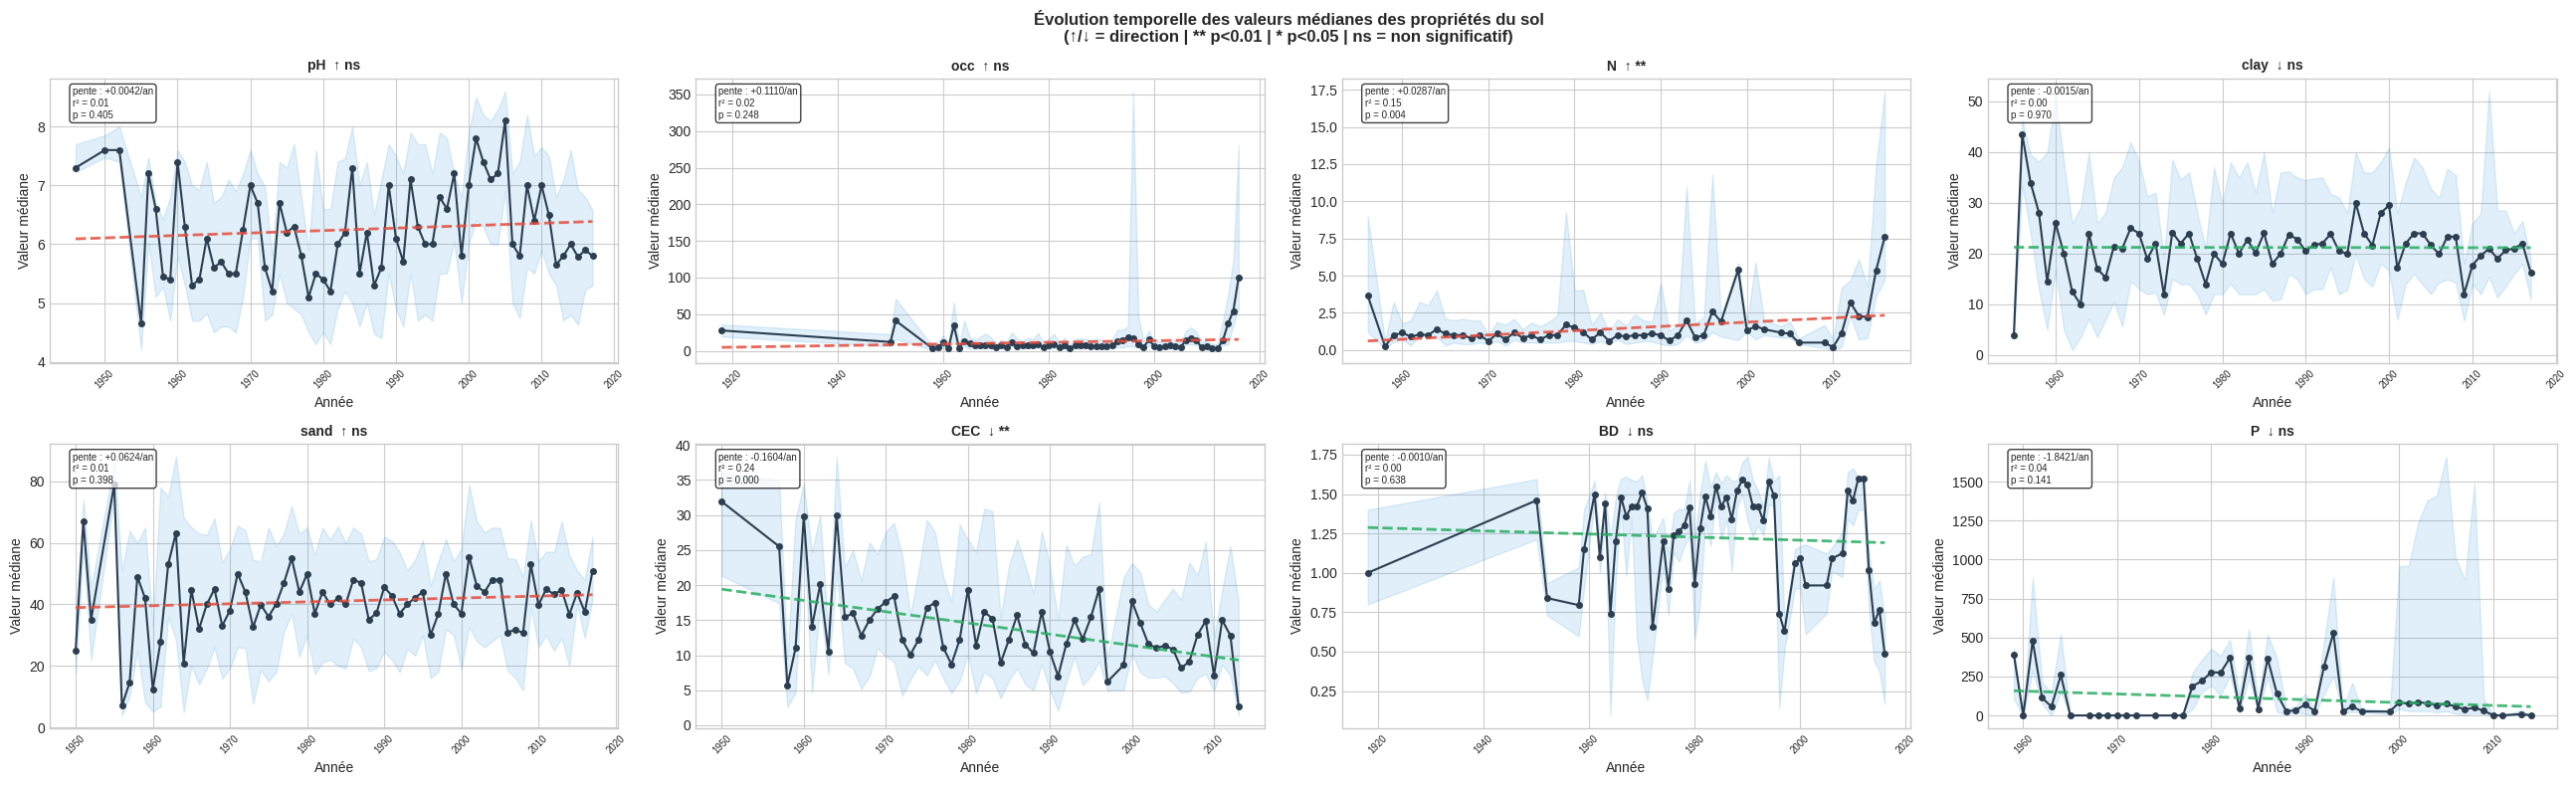


📊 TABLEAU RÉCAPITULATIF DES TENDANCES TEMPORELLES:
-----------------------------------------------------------------
           Pente (/an)     r²  p-value  Années Tendance
Propriété                                              
pH             0.00416  0.011   0.4047      66     ↑ ns
occ            0.11099  0.022   0.2482      62     ↑ ns
N              0.02873  0.146   0.0036      56     ↑ **
clay          -0.00146  0.000   0.9705      63     ↓ ns
sand           0.06245  0.011   0.3975      66     ↑ ns
CEC           -0.16043  0.237   0.0001      57     ↓ **
BD            -0.00098  0.004   0.6378      55     ↓ ns
P             -1.84206  0.045   0.1409      50     ↓ ns

📌 INTERPRÉTATION:
   • N      a significativement diminué (+0.0287/an, r²=0.15)
   • CEC    a significativement diminué (-0.1604/an, r²=0.24)

   ⚠️  Interpréter avec prudence : la couverture spatiale varie selon les années.
      Une tendance peut refléter un biais géographique plutôt qu'un vrai signal pédologique.


In [11]:

# 4.2 Évolution temporelle des VALEURS médianes par propriété
# Différent de la section précédente qui montre le nombre d'observations :
# ici on suit la valeur médiane de chaque propriété année par année.

from scipy.stats import linregress

key_props_temporal = ['pH', 'occ', 'N', 'clay', 'sand', 'CEC', 'BD', 'P']
available_temporal = [p for p in key_props_temporal if p in df_temporal['property'].unique()]

fig, axes = plt.subplots(2, 4, figsize=(26, 8))
axes = axes.flatten()

trend_summary = []

for i, prop in enumerate(available_temporal[:8]):
    ax = axes[i]

    prop_data = df_temporal[df_temporal['property'] == prop].dropna(subset=['value'])
    yearly = prop_data.groupby('year')['value'].agg(
        median='median',
        count='count',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )

    # Garder uniquement les années avec >= 10 observations
    yearly = yearly[yearly['count'] >= 10]

    if len(yearly) < 4:
        axes[i].set_visible(False)
        continue

    years_arr = yearly.index.values.astype(float)
    medians   = yearly['median'].values

    # Bande IQR
    ax.fill_between(years_arr, yearly['q25'], yearly['q75'],
                    alpha=0.15, color=COLORS[1], label='IQR 25–75')
    # Série temporelle
    ax.plot(years_arr, medians, 'o-', color=COLORS[0],
            linewidth=1.5, markersize=4, label='Médiane')

    # Régression linéaire + test de significativité
    slope, intercept, r_value, p_value, _ = linregress(years_arr, medians)
    trend_y = slope * years_arr + intercept
    trend_color = '#e74c3c' if slope > 0 else '#27ae60'  # rouge ↑, vert ↓
    ax.plot(years_arr, trend_y, '--', color=trend_color,
            linewidth=2, alpha=0.85, label=f'Tendance')

    trend_dir = '↑' if slope > 0 else '↓'
    sig_label  = '**' if p_value < 0.01 else ('*' if p_value < 0.05 else 'ns')
    ax.set_title(f'{prop}  {trend_dir} {sig_label}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Année')
    ax.set_ylabel('Valeur médiane')
    ax.tick_params(axis='x', rotation=45, labelsize=7)

    ax.text(0.04, 0.97,
            f'pente : {slope:+.4f}/an\nr² = {r_value**2:.2f}\np = {p_value:.3f}',
            transform=ax.transAxes, fontsize=7, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.75))

    trend_summary.append({
        'Propriété': prop, 'Pente (/an)': round(slope, 5),
        'r²': round(r_value**2, 3), 'p-value': round(p_value, 4),
        'Années': len(yearly), 'Tendance': f'{trend_dir} {sig_label}'
    })

# Masquer les axes inutilisés
for j in range(len(available_temporal), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Évolution temporelle des valeurs médianes des propriétés du sol\n'
    '(↑/↓ = direction | ** p<0.01 | * p<0.05 | ns = non significatif)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

# Tableau récapitulatif
print("\n📊 TABLEAU RÉCAPITULATIF DES TENDANCES TEMPORELLES:")
print("-" * 65)
summary_df = pd.DataFrame(trend_summary).set_index('Propriété')
print(summary_df.to_string())

print("\n📌 INTERPRÉTATION:")
for row in trend_summary:
    if row['p-value'] < 0.05:
        direction = 'augmenté' if '+' in row['Tendance'] else 'diminué'
        print(f"   • {row['Propriété']:6s} a significativement {direction} "
              f"({row['Pente (/an)']:+.4f}/an, r²={row['r²']:.2f})")
print("\n   ⚠️  Interpréter avec prudence : la couverture spatiale varie selon les années.")
print("      Une tendance peut refléter un biais géographique plutôt qu'un vrai signal pédologique.")


## 6. COMPARAISON DES SOURCES DE DONNÉES

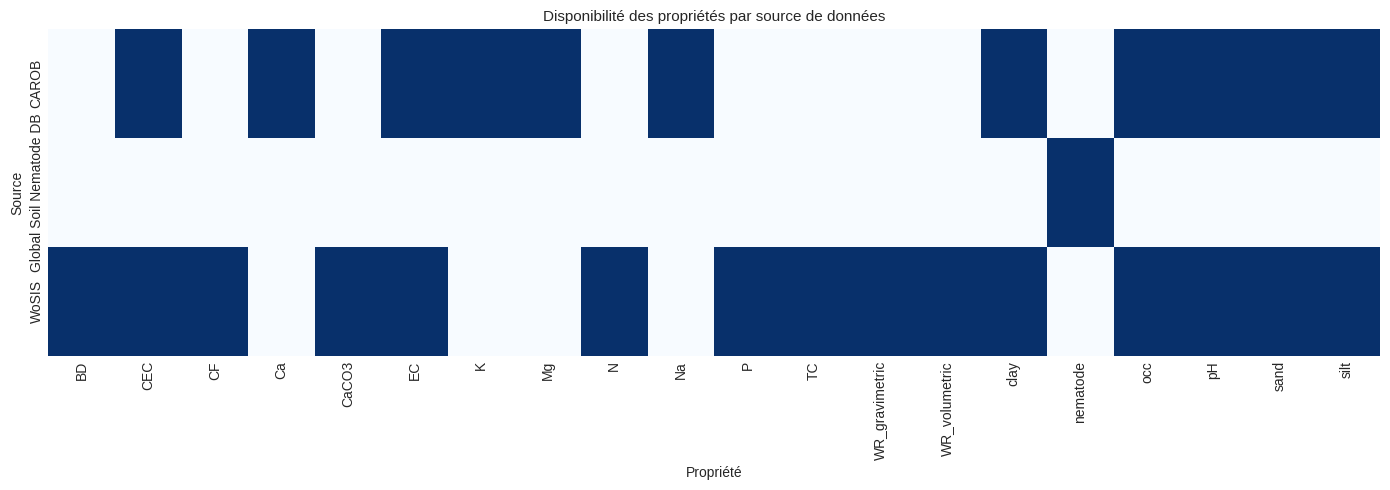


📊 PROPRIÉTÉS PAR SOURCE:
   • Global Soil Nematode DB: 1 propriétés - nematode...
   • WoSIS: 15 propriétés - BD, CEC, CF, CaCO3, EC, N, P, TC...
   • CAROB: 11 propriétés - CEC, Ca, EC, K, Mg, Na, clay, occ...


In [12]:
source_props = df.groupby(['data_source', 'property']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
source_props_binary = (source_props > 0).astype(int)
sns.heatmap(source_props_binary, cmap='Blues', cbar=False, annot=False, ax=ax)
ax.set_title('Disponibilité des propriétés par source de données')
ax.set_xlabel('Propriété')
ax.set_ylabel('Source')

plt.tight_layout()
plt.show()

print("\n📊 PROPRIÉTÉS PAR SOURCE:")
for source in df['data_source'].unique():
    props = df[df['data_source'] == source]['property'].unique()
    print(f"   • {source}: {len(props)} propriétés - {', '.join(sorted(props)[:8])}...")

## 7. CORRÉLATIONS ENTRE PROPRIÉTÉS

**Objectif:** Identifier les relations entre propriétés du sol - utile pour la sélection de features et la compréhension pédologique.

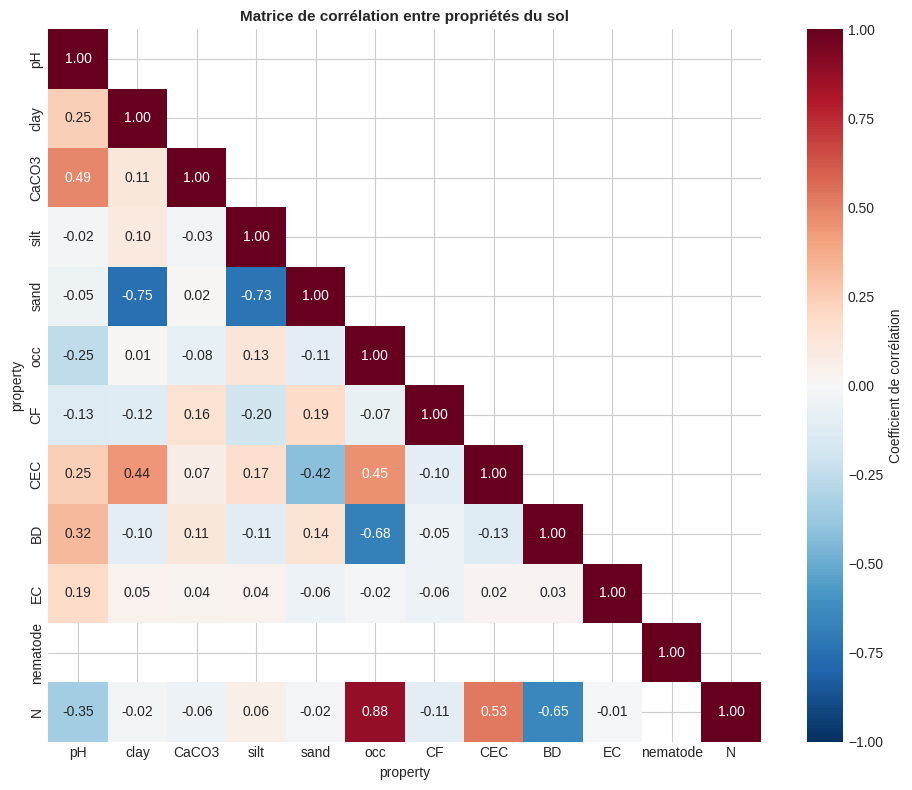


CORRÉLATIONS FORTES (|r| > 0.5):
   clay ↔ sand: r = -0.75
   silt ↔ sand: r = -0.73
   occ ↔ BD: r = -0.68
   occ ↔ N: r = +0.88
   CEC ↔ N: r = +0.53
   BD ↔ N: r = -0.65


In [13]:
# 7.1 Matrice de corrélation entre propriétés
df_pivot = df.pivot_table(
    values='value',
    index=['lat', 'lon', 'depth_mid'],
    columns='property',
    aggfunc='mean'
).reset_index()

# Sélectionner les propriétés les plus courantes
prop_counts = df['property'].value_counts()
top_props = prop_counts[prop_counts > 10000].index.tolist()[:12]

# Matrice de corrélation
if len(top_props) > 3:
    corr_matrix = df_pivot[top_props].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
                center=0, vmin=-1, vmax=1, ax=ax, square=True,
                cbar_kws={'label': 'Coefficient de corrélation'})
    ax.set_title('Matrice de corrélation entre propriétés du sol', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Identifier les corrélations fortes
    print("\nCORRÉLATIONS FORTES (|r| > 0.5):")
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > 0.5:
                sign = "+" if r > 0 else "-"
                print(f"   {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: r = {sign}{abs(r):.2f}")

## 8. SYNTHÈSE ET IMPLICATIONS POUR LA MODÉLISATION

**Objectif:** Résumer les findings clés et formuler des recommandations pour la modélisation ML (recommandation d'engrais, prédiction spatiale).

---

## CONCLUSIONS

### Points forts du dataset
1. **Volume conséquent** (~1M observations) avec bonne couverture géographique
2. **Propriétés agronomiques clés** disponibles (pH, N, texture, CEC)
3. **Index H3** pré-calculé facilitant l'agrégation spatiale
4. **Multi-source** permettant la validation croisée

### Limitations identifiées
1. **Biais temporel**: majorité des données des années 1970-1980
2. **Couverture spatiale hétérogène**: zones sous-échantillonnées
3. **Outliers significatifs**: nécessite un nettoyage rigoureux
4. **Données manquantes**: notamment pour les nutriments (P, K)

### Recommandations pour la modélisation ML
- **Pour recommandation d'engrais**: Focus sur horizon 0-30 cm, features clés = pH, N, occ, texture
- **Pour prédiction spatiale**: Utiliser krigeage ou GP avec features H3, attention aux zones clairsemées
- **Validation**: Stratifier par source et par période pour éviter le data leakage